# Heat equation with QTT/tMPS and `quimb`

This notebook solves the heat equation with an explicit Euler method while **never storing the full solution during time stepping**. The spatial vector is quantized into binary indices and stored as a tensor-train / tensor matrix product state (tMPS, also called QTT for quantized data). The finite-difference stencil is an exact matrix product operator (MPO).

We will:

1. solve the 1D heat equation on $[0,1]$ with **20 qubits** ($2^{20}$ unknowns);
2. solve the 2D heat equation on $[0,1]^2$ with **20 qubits total** ($10+10$ bits, hence $1024^2=2^{20}$ unknowns);
3. compare **stacked** ordering $(x_1,\ldots,x_n,y_1,\ldots,y_n)$ with **interleaved** ordering $(x_1,y_1,\ldots,x_n,y_n)$;
4. monitor CFL stability, error, energy, bond dimension, compression, and runtime.

The evolution and compression use `quimb`; the small `qtade_tn.py` and `qtade_quimb.py` modules in this repository provide the lecture's QTT constructors and conversion helpers.

In [12]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# Make the notebook work when launched from either the repository root or notebooks/.
cwd = Path.cwd()
if (cwd / "notebooks" / "qtade_tn.py").exists():
    sys.path.insert(0, str(cwd / "notebooks"))
elif (cwd / "qtade_tn.py").exists():
    sys.path.insert(0, str(cwd))

import qtade_quimb as qq
import qtade_tn as tn

COLORS = {"stacked": "#0072B2", "interleaved": "#D55E00", "exact": "#222222"}
plt.rcParams.update({
    "figure.figsize": (10, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("NumPy version:", np.__version__)
try:
    import quimb
    print("quimb version:", quimb.__version__)
except Exception:
    pass

NumPy version: 2.2.6
quimb version: 1.13.0


## 1. PDE, grid, and binary representation

We solve

$$
\partial_t u = \alpha\,\Delta u,
\qquad u|_{\partial\Omega}=0,
$$

with $\Omega=[0,1]$ in 1D and $\Omega=[0,1]^2$ in 2D. There are $M=2^n$ **interior** points per coordinate,

$$x_j=(j+1)h,\qquad h=\frac{1}{M+1},\qquad j=0,\ldots,M-1.$$

The missing values at $x=0$ and $x=1$ are homogeneous Dirichlet ghost values. Writing $j$ in binary turns a length-$2^n$ vector into an order-$n$ tensor with physical dimension two:

$$j=(b_1b_2\cdots b_n)_2,\qquad u_j\longleftrightarrow U(b_1,b_2,\ldots,b_n).$$

An MPS factorizes this tensor as a product of small cores. Storage is $O(n\chi^2)$ rather than $O(2^n)$ when the bond dimension $\chi$ stays small.

> **Notation warning.** Here `n_qubits` is a number of binary tensor sites. We use `M` for the number of grid points, avoiding the common ambiguity in which $N$ denotes either quantity.

In [13]:
N_QUBITS_TOTAL = 20
N_1D = N_QUBITS_TOTAL
N_PER_AXIS_2D = N_QUBITS_TOTAL // 2

M_1D = 2**N_1D
M_2D = 2**N_PER_AXIS_2D
H_1D = 1.0 / (M_1D + 1)
H_2D = 1.0 / (M_2D + 1)

print(f"1D : {N_1D:2d} qubits -> {M_1D:,} interior points, h = {H_1D:.3e}")
print(f"2D : {N_PER_AXIS_2D}+{N_PER_AXIS_2D} qubits -> "
      f"{M_2D:,} x {M_2D:,} = {M_2D**2:,} interior points, h = {H_2D:.3e}")
print(f"Both problems have exactly {2**N_QUBITS_TOTAL:,} scalar unknowns.")

1D : 20 qubits -> 1,048,576 interior points, h = 9.537e-07
2D : 10+10 qubits -> 1,024 x 1,024 = 1,048,576 interior points, h = 9.756e-04
Both problems have exactly 1,048,576 scalar unknowns.


## 2. Analytic QTT cores for sine modes

The Dirichlet eigenvectors are

$$s_m(j)=\sin\!\left(\frac{m\pi(j+1)}{M+1}\right).$$

They have an exact rank-2 QTT representation. The reason is the angle-addition identity. If a bond carries $(\cos\theta,\sin\theta)$, reading bit $b_k$ rotates it by

$$b_k\,m\pi h\,2^{n-1-k}.$$

Thus each bit is a $2\times2$ rotation and the bond dimension never depends on $M$. This is a useful example of the central QTT idea: **rank follows algebraic structure, not the number of samples**.

In [14]:
def qtt_sine(n, mode, h=None):
    '''Exact real rank-2 QTT cores for sin(mode*pi*x_j), x_j=(j+1)h.

    Cores use the repository convention (left bond, physical bit, right bond),
    with the most-significant bit first.
    '''
    M = 2**n
    h = 1.0 / (M + 1) if h is None else h
    offset = mode * np.pi * h
    start = np.array([np.cos(offset), np.sin(offset)])
    finish = np.array([0.0, 1.0])

    rotations = []
    for k in range(n):
        angle = mode * np.pi * h * 2**(n - 1 - k)
        c, s = np.cos(angle), np.sin(angle)
        R = np.array([[c, s], [-s, c]])
        W = np.stack([np.eye(2), R], axis=0)  # physical bit, left, right
        rotations.append(W)

    if n == 1:
        core = np.empty((1, 2, 1))
        for bit in (0, 1):
            core[0, bit, 0] = start @ rotations[0][bit] @ finish
        return [core]

    cores = []
    first = np.empty((1, 2, 2))
    for bit in (0, 1):
        first[0, bit, :] = start @ rotations[0][bit]
    cores.append(first)

    for W in rotations[1:-1]:
        cores.append(W.transpose(1, 0, 2).copy())

    last = np.empty((2, 2, 1))
    for bit in (0, 1):
        last[:, bit, 0] = rotations[-1][bit] @ finish
    cores.append(last)
    return cores


def combine_terms(terms, eps=1e-14):
    '''Add (coefficient, core_list) terms and round the result.'''
    out = None
    for coefficient, cores in terms:
        scaled = tn.tt_scale(cores, coefficient)
        out = scaled if out is None else tn.tt_add(out, scaled)
    return tn.tt_round(out, eps=eps)


def state_1d(n, modal_coefficients):
    '''modal_coefficients is an iterable of (coefficient, mode).'''
    return combine_terms([(a, qtt_sine(n, m)) for a, m in modal_coefficients])


def product_mode_2d(n, mx, my, ordering):
    '''QTT cores for sin(mx*pi*x) sin(my*pi*y) in the requested bit order.'''
    cx, cy = qtt_sine(n, mx), qtt_sine(n, my)
    if ordering == "stacked":
        # The rank-one bond between the two trains multiplies f(x) by g(y).
        return cx + cy
    if ordering == "interleaved":
        # Splice carries both partial phase states while alternating x and y bits.
        return qq._splice(cx, cy)
    raise ValueError("ordering must be 'stacked' or 'interleaved'")


def state_2d(n, modal_coefficients, ordering):
    '''modal_coefficients contains (coefficient, (mx, my)).'''
    return combine_terms([
        (a, product_mode_2d(n, mx, my, ordering))
        for a, (mx, my) in modal_coefficients
    ])


# A small dense check is appropriate here; the actual solves below never need this.
n_check, mode_check = 8, 17
cores_check = qtt_sine(n_check, mode_check)
x_check = np.arange(1, 2**n_check + 1) / (2**n_check + 1)
u_check = tn.qtt_to_vector(cores_check)
u_check_exact = np.sin(mode_check * np.pi * x_check)

print("QTT sine ranks:", tn.tt_ranks(cores_check))
print("maximum pointwise construction error:",
      f"{np.max(np.abs(u_check - u_check_exact)):.3e}")

QTT sine ranks: [1, 2, 2, 2, 2, 2, 2, 2, 1]
maximum pointwise construction error: 8.410e-15


## 3. Finite-difference Laplacian as an MPO

Let $S_+$ and $S_-$ be zero-padded shifts. In one dimension,

$$
L_h=\frac{S_+ + S_- - 2I}{h^2}.
$$

Each shift is a rank-2 binary carry automaton, so $L_h$ has an exact, resolution-independent QTT/MPO rank. In two dimensions,

$$L_h^{(2D)}=L_h\otimes I + I\otimes L_h.$$

Explicit Euler is

$$u^{k+1}=\left(I+\alpha\Delta t\,L_h\right)u^k.$$

Writing $\mu=\alpha\Delta t/h^2$ lets us build the numerically better-scaled dimensionless MPO

$$E=I+\mu\,(S_+ + S_- - 2I)$$

in 1D, with the sum of the two coordinate operators in 2D. Every timestep is an MPO--MPS product followed by SVD compression.

In [15]:
def euler_mpo_1d(n, mu):
    laplacian_no_h = tn.qtt_laplacian(n, dx=1.0)
    step = tn.mpo_add(tn.mpo_identity(n), tn.mpo_scale(laplacian_no_h, mu))
    step = tn.mpo_round(step, eps=1e-14)
    return qq.to_mpo(step), step


def euler_mpo_2d(n, mu, ordering):
    laplacian_no_h = qq.laplacian_2d(n, h=1.0, ordering=ordering)
    step = tn.mpo_add(tn.mpo_identity(2 * n), tn.mpo_scale(laplacian_no_h, mu))
    step = tn.mpo_round(step, eps=1e-14)
    return qq.to_mpo(step), step


def discrete_euler_factor_1d(mode, M, mu):
    '''One-step amplification of the Dirichlet sine eigenmode.'''
    return 1.0 - 4.0 * mu * np.sin(mode * np.pi / (2.0 * (M + 1)))**2


def discrete_euler_factor_2d(modes, M, mu):
    mx, my = modes
    sx = np.sin(mx * np.pi / (2.0 * (M + 1)))**2
    sy = np.sin(my * np.pi / (2.0 * (M + 1)))**2
    return 1.0 - 4.0 * mu * (sx + sy)


step_1d, step_1d_cores = euler_mpo_1d(N_1D, mu=0.45)
print("1D explicit-Euler MPO ranks:", tn.mpo_ranks(step_1d_cores))
print("1D explicit-Euler MPO max rank:", max(tn.mpo_ranks(step_1d_cores)))

1D explicit-Euler MPO ranks: [1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1]
1D explicit-Euler MPO max rank: 3


## 4. CFL stability is unchanged by compression

For a Fourier component with grid angle $\theta$, the 1D amplification factor is

$$G(\theta)=1-4\mu\sin^2(\theta/2).$$

In $d$ dimensions the contributions add. Requiring $|G|\le 1$ for every resolvable mode gives

$$\boxed{\mu=\frac{\alpha\Delta t}{h^2}\le\frac{1}{2d}}.$$

Therefore the limits are $1/2$ in 1D and $1/4$ in 2D. QTT changes how the vector and operator are stored; it does **not** change this stability region. Compression cannot repair a timestep outside the CFL limit.

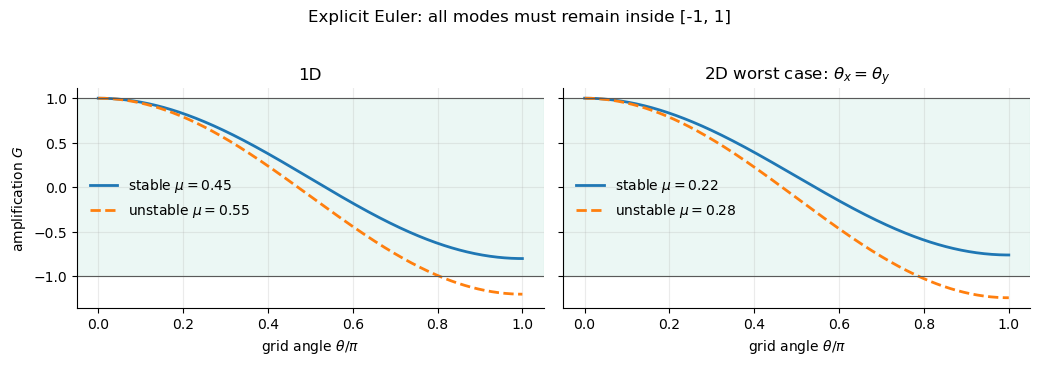

In [16]:
theta = np.linspace(0.0, np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5), sharey=True)

for mu, style, label in [(0.45, "-", r"stable $\mu=0.45$"),
                         (0.55, "--", r"unstable $\mu=0.55$")]:
    G = 1.0 - 4.0 * mu * np.sin(theta / 2.0)**2
    axes[0].plot(theta / np.pi, G, style, lw=2, label=label)

for mu, style, label in [(0.22, "-", r"stable $\mu=0.22$"),
                         (0.28, "--", r"unstable $\mu=0.28$")]:
    G = 1.0 - 8.0 * mu * np.sin(theta / 2.0)**2  # worst 2D line: theta_x=theta_y
    axes[1].plot(theta / np.pi, G, style, lw=2, label=label)

for ax, title in zip(axes, ["1D", r"2D worst case: $\theta_x=\theta_y$"]):
    ax.axhspan(-1, 1, color="#009E73", alpha=0.08)
    ax.axhline(1, color="0.35", lw=0.8)
    ax.axhline(-1, color="0.35", lw=0.8)
    ax.set(xlabel=r"grid angle $\theta/\pi$", title=title)
    ax.legend(frameon=False)
axes[0].set_ylabel(r"amplification $G$")
fig.suptitle("Explicit Euler: all modes must remain inside [-1, 1]", y=1.03)
plt.tight_layout()

## 5. Diagnostics without dense reconstruction

The error and norm below are contracted directly from QTT cores. No length-$2^{20}$ vector is formed inside the time loop.

We compare against two references:

- **exact discrete Euler:** each sine coefficient is multiplied by the known finite-difference amplification factor; disagreement measures MPO application and MPS truncation error;
- **continuous PDE:** each coefficient is multiplied by $\exp[-\alpha\pi^2(m_x^2+m_y^2)t]$; disagreement also contains spatial and temporal discretization error.

The initial condition mixes a smooth mode with a moderate high-frequency mode. The high mode is chosen at $M/16$, so diffusion is visible within 40 CFL-limited steps while the QTT rank remains analytically small.

In [17]:
def relative_l2_from_cores(approx_mps, reference_cores):
    '''Relative L2 error, forming and contracting only a low-rank difference.'''
    approx_cores = qq.cores(approx_mps)
    difference = tn.tt_add(approx_cores, tn.tt_scale(reference_cores, -1.0))
    difference = tn.tt_round(difference, eps=1e-14)
    return tn.tt_norm(difference) / tn.tt_norm(reference_cores)


def evolve(step_mpo, initial_cores, exact_euler, exact_continuum,
           n_steps, dense_size, cutoff=1e-12, max_bond=64):
    '''Apply an Euler MPO repeatedly with quimb compression and collect metrics.'''
    u = qq.to_mps(initial_cores)
    norm0 = tn.tt_norm(initial_cores)
    history = {name: [] for name in [
        "step", "time", "error_euler", "error_continuum", "energy_ratio",
        "max_bond", "parameters", "compression", "wall_time"
    ]}
    elapsed = 0.0

    for k in range(n_steps + 1):
        if k:
            tic = time.perf_counter()
            # Apply exactly, then compress with an explicit *relative singular-value*
            # cutoff. Naming the mode makes this reproducible across quimb versions:
            # older releases defaulted to a cumulative-squared cutoff instead.
            u = step_mpo.apply(u)
            u.compress(max_bond=max_bond, cutoff=cutoff, cutoff_mode="rel")
            elapsed += time.perf_counter() - tic

        cores = qq.cores(u)
        ref_euler = exact_euler(k)
        ref_continuum = exact_continuum(k)
        n_parameters = sum(core.size for core in cores)

        history["step"].append(k)
        history["time"].append(exact_continuum.time(k))
        history["error_euler"].append(relative_l2_from_cores(u, ref_euler))
        history["error_continuum"].append(relative_l2_from_cores(u, ref_continuum))
        history["energy_ratio"].append((tn.tt_norm(cores) / norm0)**2)
        history["max_bond"].append(max(tn.tt_ranks(cores)))
        history["parameters"].append(n_parameters)
        history["compression"].append(dense_size / n_parameters)
        history["wall_time"].append(elapsed)

    return u, {key: np.asarray(value) for key, value in history.items()}


def dense_2d(mps_or_cores, n, ordering):
    '''Diagnostic-only dense readout, performed after evolution for plotting.'''
    cores = qq.cores(mps_or_cores) if not isinstance(mps_or_cores, list) else mps_or_cores
    tensor = tn.tt_full(cores)
    if ordering == "interleaved":
        permutation = list(range(0, 2 * n, 2)) + list(range(1, 2 * n, 2))
        tensor = tensor.transpose(permutation)
    return tensor.reshape(2**n, 2**n)


class Reference:
    '''Callable reference state with its physical timestep attached.'''
    def __init__(self, builder, dt):
        self.builder = builder
        self.dt = dt

    def __call__(self, step):
        return self.builder(step)

    def time(self, step):
        return step * self.dt

## 6. One-dimensional solve: 20 qubits

We take $\alpha=1$, $\mu=0.45$, and therefore $\Delta t=0.45h^2$. At this resolution a macroscopic final time would require tens of billions of explicit steps. That is not a tensor-network limitation; it is the parabolic CFL restriction. Explicit Euler is used here because its mechanics and stability are transparent. Practical fine-grid solvers normally use implicit, IMEX, exponential, or multilevel time integration.

In [18]:
alpha = 1.0
mu_1d = 0.45
dt_1d = mu_1d * H_1D**2 / alpha
n_steps = 40
high_mode_1d = M_1D // 16
modes_1d = [(1.0, 1), (0.20, high_mode_1d)]

u0_1d = state_1d(N_1D, modes_1d)
step_1d, step_1d_cores = euler_mpo_1d(N_1D, mu_1d)

def build_euler_1d(k):
    return state_1d(N_1D, [
        (a * discrete_euler_factor_1d(m, M_1D, mu_1d)**k, m)
        for a, m in modes_1d
    ])

def build_continuum_1d(k):
    t = k * dt_1d
    return state_1d(N_1D, [
        (a * np.exp(-alpha * (m * np.pi)**2 * t), m)
        for a, m in modes_1d
    ])

ref_euler_1d = Reference(build_euler_1d, dt_1d)
ref_continuum_1d = Reference(build_continuum_1d, dt_1d)

u_1d, hist_1d = evolve(
    step_1d, u0_1d, ref_euler_1d, ref_continuum_1d,
    n_steps=n_steps, dense_size=M_1D, cutoff=1e-12, max_bond=64,
)

steps_to_001 = int(np.ceil(0.01 / dt_1d))
print(f"dt = {dt_1d:.3e}; final t = {hist_1d['time'][-1]:.3e}")
print(f"steps needed to reach t=0.01: {steps_to_001:,}")
print(f"Euler MPO max bond: {max(tn.mpo_ranks(step_1d_cores))}")
print(f"final MPS max bond: {hist_1d['max_bond'][-1]}")
print(f"final tMPS / exact-Euler relative error: {hist_1d['error_euler'][-1]:.3e}")
print(f"final tMPS / continuous-PDE relative error: {hist_1d['error_continuum'][-1]:.3e}")
print(f"final dense/MPS storage ratio: {hist_1d['compression'][-1]:,.0f}x")
print(f"time stepping wall time: {hist_1d['wall_time'][-1]:.2f} s")

dt = 4.093e-13; final t = 1.637e-11
steps needed to reach t=0.01: 24,433,638,332
Euler MPO max bond: 3
final MPS max bond: 4
final tMPS / exact-Euler relative error: 5.197e-13
final tMPS / continuous-PDE relative error: 3.795e-04
final dense/MPS storage ratio: 1,900x
time stepping wall time: 0.17 s


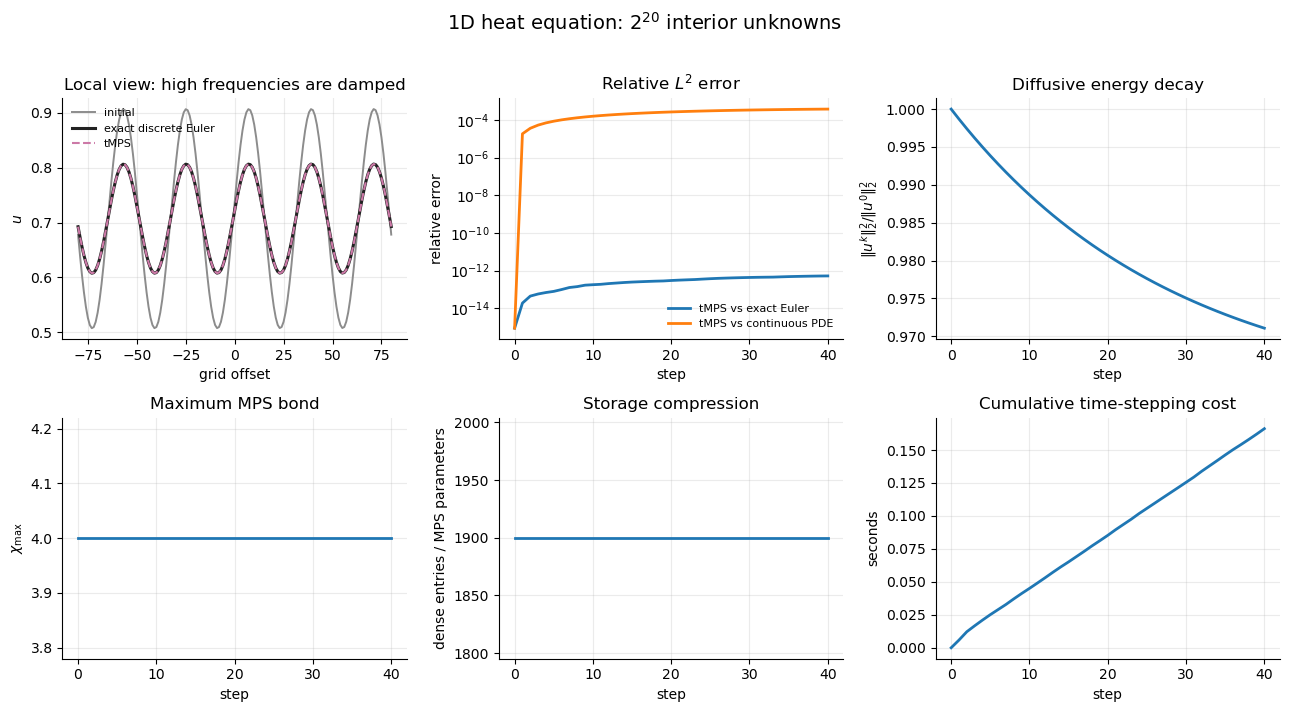

In [19]:
# Dense readout is used only once, after the solve, to make the teaching figure.
u0_dense_1d = tn.qtt_to_vector(u0_1d)
u_dense_1d = tn.qtt_to_vector(qq.cores(u_1d))
u_ref_dense_1d = tn.qtt_to_vector(build_euler_1d(n_steps))

centre = M_1D // 4
window = slice(centre - 80, centre + 81)
offset = np.arange(-80, 81)

fig, axes = plt.subplots(2, 3, figsize=(13, 7.0))
ax = axes[0, 0]
ax.plot(offset, u0_dense_1d[window], color="0.55", lw=1.4, label="initial")
ax.plot(offset, u_ref_dense_1d[window], color=COLORS["exact"], lw=2.2,
        label="exact discrete Euler")
ax.plot(offset, u_dense_1d[window], "--", color="#CC79A7", lw=1.5, label="tMPS")
ax.set(title="Local view: high frequencies are damped", xlabel="grid offset", ylabel="$u$")
ax.legend(frameon=False, fontsize=8)

axes[0, 1].semilogy(hist_1d["step"], np.maximum(hist_1d["error_euler"], 1e-16),
                     lw=2, label="tMPS vs exact Euler")
axes[0, 1].semilogy(hist_1d["step"], np.maximum(hist_1d["error_continuum"], 1e-16),
                     lw=2, label="tMPS vs continuous PDE")
axes[0, 1].set(title="Relative $L^2$ error", xlabel="step", ylabel="relative error")
axes[0, 1].legend(frameon=False, fontsize=8)

axes[0, 2].plot(hist_1d["step"], hist_1d["energy_ratio"], lw=2)
axes[0, 2].set(title="Diffusive energy decay", xlabel="step", ylabel=r"$\|u^k\|_2^2/\|u^0\|_2^2$")

axes[1, 0].step(hist_1d["step"], hist_1d["max_bond"], where="mid", lw=2)
axes[1, 0].set(title="Maximum MPS bond", xlabel="step", ylabel=r"$\chi_{\max}$")

axes[1, 1].plot(hist_1d["step"], hist_1d["compression"], lw=2)
axes[1, 1].set(title="Storage compression", xlabel="step", ylabel="dense entries / MPS parameters")

axes[1, 2].plot(hist_1d["step"], hist_1d["wall_time"], lw=2)
axes[1, 2].set(title="Cumulative time-stepping cost", xlabel="step", ylabel="seconds")

fig.suptitle(r"1D heat equation: $2^{20}$ interior unknowns", fontsize=14, y=1.01)
plt.tight_layout()

### Reading the 1D diagnostics

- The tMPS curve should be visually indistinguishable from exact discrete Euler; their difference is only the controlled SVD truncation and floating-point error.
- The larger error against the continuous PDE is expected: it includes both finite-difference dispersion and first-order time discretization.
- The $L^2$ energy decays, as it should for homogeneous Dirichlet heat flow.
- Bond dimension stays small because the solution remains a sum of two sine modes. This is an intentionally favorable, analytically interpretable case—not a guarantee that arbitrary heat data has low QTT rank.
- The enormous step count required for $t=0.01$ is the key warning about explicit parabolic timestepping at very fine spatial resolution.

## 7. Two-dimensional solve: stacked versus interleaved

With 20 qubits total we use 10 bits per coordinate. The two orderings encode the same $1024\times1024$ array:

$$
\begin{aligned}
\text{stacked: }& (x_1,x_2,\ldots,x_{10},y_1,y_2,\ldots,y_{10}),\\
\text{interleaved: }& (x_1,y_1,x_2,y_2,\ldots,x_{10},y_{10}).
\end{aligned}
$$

Stacked ordering places all $x$--$y$ separation at one cut and is often excellent for sums of separable functions. Interleaving keeps equal spatial scales adjacent and can be better when correlations are local in scale. There is no universally optimal choice: the rank profile is data- and operator-dependent.

For 2D explicit Euler the CFL limit is $\mu\le1/4$; we use $\mu=0.22$.

In [20]:
mu_2d = 0.22
dt_2d = mu_2d * H_2D**2 / alpha
high_mode_2d = M_2D // 16
modes_2d = [(1.0, (1, 1)), (0.20, (high_mode_2d, high_mode_2d))]

results_2d = {}
for ordering in ("stacked", "interleaved"):
    print(f"Running {ordering} ordering ...")
    u0 = state_2d(N_PER_AXIS_2D, modes_2d, ordering)
    step_mpo, step_cores = euler_mpo_2d(N_PER_AXIS_2D, mu_2d, ordering)

    def build_euler_2d(k, ordering=ordering):
        return state_2d(N_PER_AXIS_2D, [
            (a * discrete_euler_factor_2d(mxy, M_2D, mu_2d)**k, mxy)
            for a, mxy in modes_2d
        ], ordering)

    def build_continuum_2d(k, ordering=ordering):
        t = k * dt_2d
        return state_2d(N_PER_AXIS_2D, [
            (a * np.exp(-alpha * np.pi**2 * (mxy[0]**2 + mxy[1]**2) * t), mxy)
            for a, mxy in modes_2d
        ], ordering)

    ref_euler = Reference(build_euler_2d, dt_2d)
    ref_continuum = Reference(build_continuum_2d, dt_2d)
    u, history = evolve(
        step_mpo, u0, ref_euler, ref_continuum,
        n_steps=n_steps, dense_size=M_2D**2, cutoff=1e-12, max_bond=64,
    )
    results_2d[ordering] = {
        "u0": u0, "u": u, "history": history,
        "step_cores": step_cores, "exact_final": build_euler_2d(n_steps),
    }

print(f"\ndt = {dt_2d:.3e}; final t = {n_steps * dt_2d:.3e}")
print("ordering       MPO chi   final MPS chi   rel.err(Euler)   compression   wall time")
for ordering, result in results_2d.items():
    hst = result["history"]
    print(f"{ordering:11s} {max(tn.mpo_ranks(result['step_cores'])):8d} "
          f"{int(hst['max_bond'][-1]):15d} {hst['error_euler'][-1]:16.3e} "
          f"{hst['compression'][-1]:11.0f}x {hst['wall_time'][-1]:9.2f} s")

Running stacked ordering ...
Running interleaved ordering ...

dt = 2.094e-07; final t = 8.376e-06
ordering       MPO chi   final MPS chi   rel.err(Euler)   compression   wall time
stacked            4               4        1.245e-13        2016x      0.18 s
interleaved        5               8        1.658e-13         535x      0.21 s


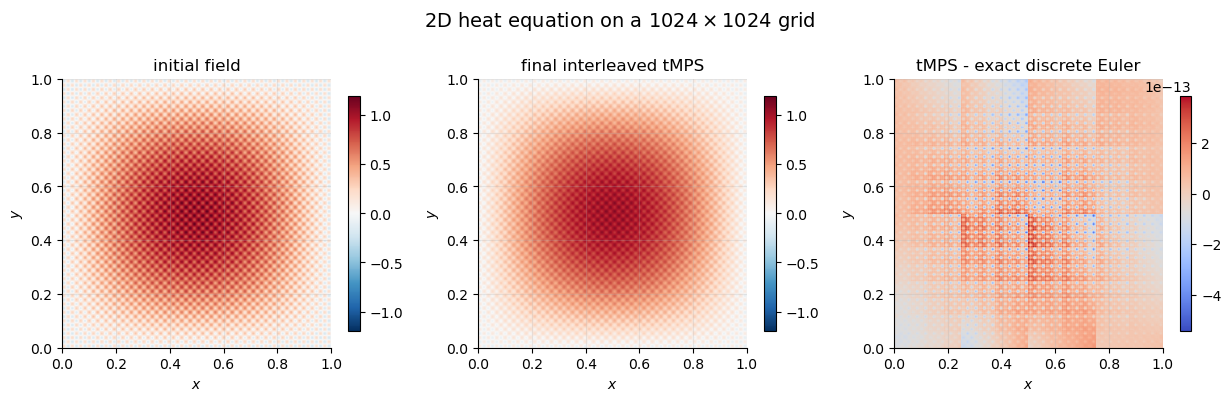

In [21]:
# Dense reconstruction only for final visualization (not part of the solver).
u0_grid = dense_2d(results_2d["interleaved"]["u0"], N_PER_AXIS_2D, "interleaved")
uf_grid = dense_2d(results_2d["interleaved"]["u"], N_PER_AXIS_2D, "interleaved")
ref_grid = dense_2d(results_2d["interleaved"]["exact_final"], N_PER_AXIS_2D, "interleaved")

vmax = max(np.max(np.abs(u0_grid)), np.max(np.abs(uf_grid)))
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
images = [u0_grid, uf_grid, uf_grid - ref_grid]
titles = ["initial field", "final interleaved tMPS", "tMPS - exact discrete Euler"]
cmaps = ["RdBu_r", "RdBu_r", "coolwarm"]
limits = [(-vmax, vmax), (-vmax, vmax), (None, None)]

for ax, image, title, cmap, lim in zip(axes, images, titles, cmaps, limits):
    kwargs = {} if lim[0] is None else {"vmin": lim[0], "vmax": lim[1]}
    im = ax.imshow(image.T, origin="lower", extent=(0, 1, 0, 1),
                   interpolation="nearest", cmap=cmap, **kwargs)
    ax.set(title=title, xlabel="$x$", ylabel="$y$")
    fig.colorbar(im, ax=ax, shrink=0.82)

fig.suptitle(r"2D heat equation on a $1024\times1024$ grid", fontsize=14, y=1.02)
plt.tight_layout()

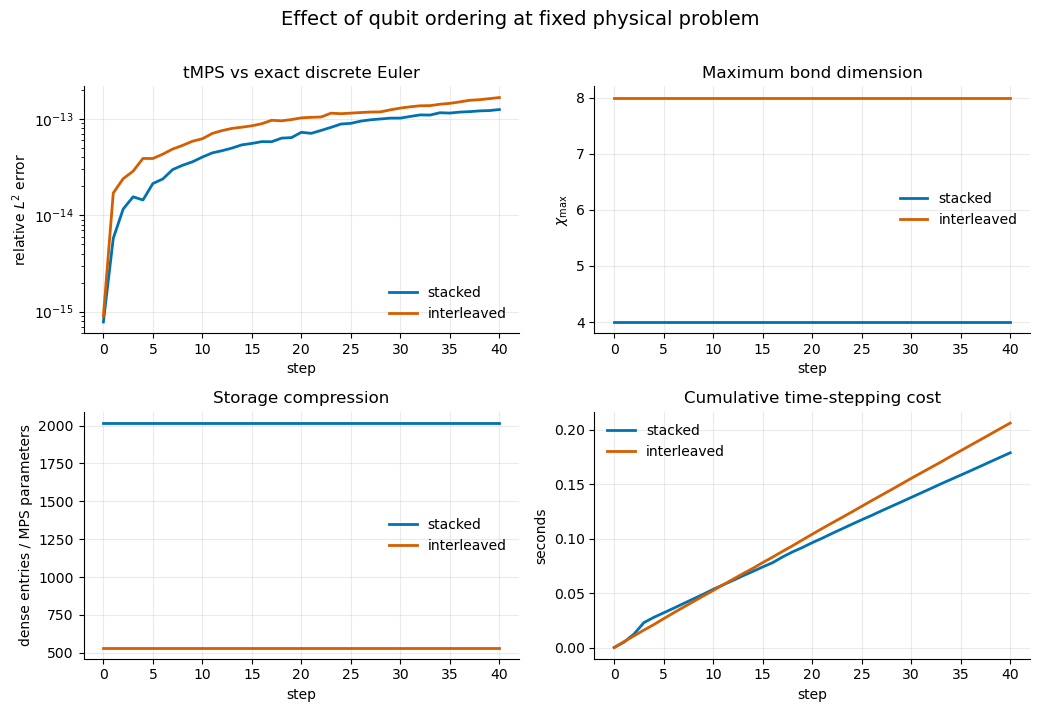

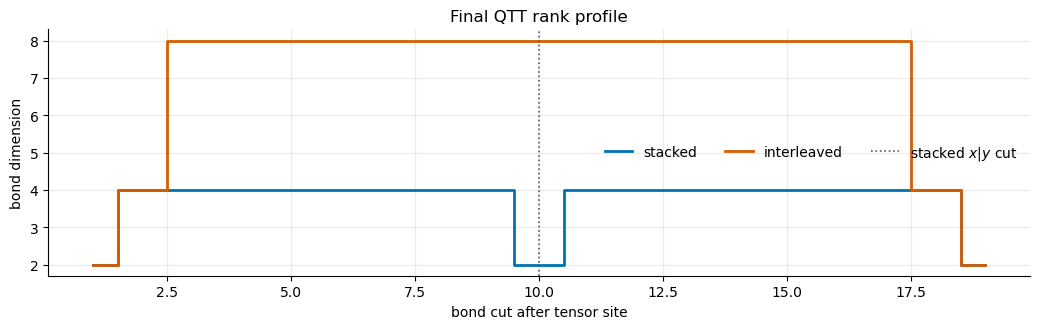

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0))
for ordering, result in results_2d.items():
    hst = result["history"]
    color = COLORS[ordering]
    axes[0, 0].semilogy(hst["step"], np.maximum(hst["error_euler"], 1e-16),
                        lw=2, color=color, label=ordering)
    axes[0, 1].step(hst["step"], hst["max_bond"], where="mid",
                    lw=2, color=color, label=ordering)
    axes[1, 0].plot(hst["step"], hst["compression"],
                    lw=2, color=color, label=ordering)
    axes[1, 1].plot(hst["step"], hst["wall_time"],
                    lw=2, color=color, label=ordering)

axes[0, 0].set(title="tMPS vs exact discrete Euler", xlabel="step", ylabel="relative $L^2$ error")
axes[0, 1].set(title="Maximum bond dimension", xlabel="step", ylabel=r"$\chi_{\max}$")
axes[1, 0].set(title="Storage compression", xlabel="step", ylabel="dense entries / MPS parameters")
axes[1, 1].set(title="Cumulative time-stepping cost", xlabel="step", ylabel="seconds")
for ax in axes.flat:
    ax.legend(frameon=False)
fig.suptitle("Effect of qubit ordering at fixed physical problem", fontsize=14, y=1.01)
plt.tight_layout()


# Bond dimensions at every cut reveal where each ordering stores correlations.
fig, ax = plt.subplots(figsize=(10.5, 3.4))
for ordering, result in results_2d.items():
    ranks = tn.tt_ranks(qq.cores(result["u"]))[1:-1]
    ax.step(np.arange(1, N_QUBITS_TOTAL), ranks, where="mid", lw=2,
            color=COLORS[ordering], label=ordering)
ax.axvline(N_PER_AXIS_2D, color="0.35", ls=":", lw=1.2,
           label="stacked $x|y$ cut")
ax.set(xlabel="bond cut after tensor site", ylabel="bond dimension",
       title="Final QTT rank profile")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()

## 8. What this example demonstrates—and what it does not

1. **The grid is genuinely large.** Both solves contain $2^{20}=1{,}048{,}576$ scalar degrees of freedom, but the time loop manipulates only QTT/MPS and MPO cores.
2. **The finite-difference operator is exact in QTT.** Binary shift automata give a small, resolution-independent MPO rank.
3. **Compression is part of the algorithm.** An MPO application multiplies bond dimensions; the SVD truncation after every step prevents exponential rank growth.
4. **CFL still rules explicit Euler.** In 1D, resolving $2^{20}$ interior points makes $\Delta t=O(2^{-40})$. QTT compresses space, not physical stiffness.
5. **Ordering changes ranks and cost, not the represented field.** Stacked ordering is naturally favorable for this sum of separable sine products. Interleaving may become favorable for fields whose $x$--$y$ correlations align by spatial scale.
6. **Low rank is problem-dependent.** A two-mode initial condition remains extremely compressible. Discontinuous data, moving fronts, nonlinearities, or irregular boundaries can increase ranks substantially.

Natural extensions for students are to change the modal content, tighten or loosen the truncation tolerance, deliberately violate the CFL limit, or replace explicit Euler by an implicit solve $(I-\alpha\Delta t L_h)u^{k+1}=u^k$.

## 9. Suggested experiments

- Set `mu_1d = 0.55` or `mu_2d = 0.28`, include a near-Nyquist sine mode, and observe the unstable amplification.
- Increase the number of modes in the initial condition and compare bond growth.
- Replace the separable 2D data by a rotated Gaussian or a diagonal feature; then re-run the ordering comparison.
- Sweep `cutoff` from `1e-6` to `1e-13` and plot error versus storage and runtime.
- Compare the explicit scheme with the implicit QTT linear solve used elsewhere in the lecture.

The most important diagnostic is not only the field plot: always inspect error, rank, compression, and wall time together.

## 10. Long-time dynamics on reduced grids

The 20-qubit calculations above are useful resolution and compression benchmarks, but the parabolic CFL condition makes their physical time interval tiny. To visualize an appreciable diffusion time with explicit Euler, we now reduce the grids:

- **1D:** $2^8=256$ interior points;
- **2D:** $2^6\times2^6=64\times64$ interior points, or 12 qubits total.

The smaller grids let us take thousands of stable Euler steps and create animations. We also leave the analytically convenient two-mode example behind and use **two different, non-modal initial conditions in each dimension**. Dense arrays are used only for constructing these small-grid initial conditions, reference solutions, and visualization; every numerical timestep still applies a QTT/MPO to a tMPS and compresses it with `quimb`.

These animation grids are intentionally small enough that MPS bookkeeping can exceed dense storage (a reported compression ratio below one). The storage advantage belongs to the 20-qubit benchmark above; this section is about resolving physical time and observing rank dynamics.

The reference calculation diagonalizes the same Dirichlet finite-difference Laplacian with a discrete sine transform (DST):

- the **dense Euler reference** uses exactly the same Euler amplification factors and isolates QTT truncation error;
- the **semi-discrete heat reference** uses the matrix exponential $e^{\alpha tL_h}$ and exposes Euler time-discretization error.

In [23]:
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.fft import dst, dstn, idst, idstn
from IPython.display import Image, display


def repository_root():
    here = Path.cwd()
    if (here / "notebooks").is_dir() and (here / "notes").is_dir():
        return here
    if here.name == "notebooks" and (here.parent / "notes").is_dir():
        return here.parent
    raise RuntimeError("Launch this notebook from the repository root or notebooks/.")


FIGURE_DIR = repository_root() / "notes" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

N_LONG_1D = 8
M_LONG_1D = 2**N_LONG_1D
H_LONG_1D = 1.0 / (M_LONG_1D + 1)
MU_LONG_1D = 0.45
DT_LONG_1D = MU_LONG_1D * H_LONG_1D**2 / alpha
T_FINAL_1D = 0.020
STEPS_LONG_1D = int(np.ceil(T_FINAL_1D / DT_LONG_1D))

N_LONG_2D = 6
M_LONG_2D = 2**N_LONG_2D
H_LONG_2D = 1.0 / (M_LONG_2D + 1)
MU_LONG_2D = 0.22
DT_LONG_2D = MU_LONG_2D * H_LONG_2D**2 / alpha
T_FINAL_2D = 0.030
STEPS_LONG_2D = int(np.ceil(T_FINAL_2D / DT_LONG_2D))

N_ANIMATION_FRAMES = 61

print(f"1D long run: {M_LONG_1D} points, {STEPS_LONG_1D:,} steps, "
      f"dt={DT_LONG_1D:.3e}, final t={STEPS_LONG_1D * DT_LONG_1D:.4f}")
print(f"2D long run: {M_LONG_2D} x {M_LONG_2D} points, {STEPS_LONG_2D:,} steps, "
      f"dt={DT_LONG_2D:.3e}, final t={STEPS_LONG_2D * DT_LONG_2D:.4f}")

1D long run: 256 points, 2,936 steps, dt=6.813e-06, final t=0.0200
2D long run: 64 x 64 points, 577 steps, dt=5.207e-05, final t=0.0300


### Long-run helpers

The routines below record only 61 diagnostic frames, although every Euler step is performed. `cutoff_mode="rel"` is set explicitly so that the truncation tolerance has the same meaning across `quimb` versions. The animations and reference errors are computed only at recorded times.

In [24]:
def apply_and_compress(mpo, mps, cutoff=1e-11, max_bond=64):
    '''One exact MPO--MPS product followed by a relative-SVD compression.'''
    out = mpo.apply(mps)
    out.compress(max_bond=max_bond, cutoff=cutoff, cutoff_mode="rel")
    return out


def relative_dense_error(approximation, reference):
    denominator = max(np.linalg.norm(reference.ravel()), np.finfo(float).tiny)
    return np.linalg.norm((approximation - reference).ravel()) / denominator


def record_steps(n_steps, n_frames=N_ANIMATION_FRAMES):
    return np.unique(np.linspace(0, n_steps, n_frames, dtype=int))


def run_long_1d(u0, cutoff=1e-11, max_bond=64):
    '''Long 1D QTT evolution plus DST-based Euler and semi-discrete references.'''
    initial_cores = tn.qtt_from_vector(u0, eps=1e-13, chi_max=max_bond)
    u = qq.to_mps(initial_cores)
    step_mpo, step_cores = euler_mpo_1d(N_LONG_1D, MU_LONG_1D)

    modes = np.arange(1, M_LONG_1D + 1)
    eigenvalues = -4.0 / H_LONG_1D**2 * np.sin(
        modes * np.pi / (2.0 * (M_LONG_1D + 1))
    )**2
    coefficients = dst(u0, type=1, norm="ortho")
    euler_factors = 1.0 + alpha * DT_LONG_1D * eigenvalues

    wanted = record_steps(STEPS_LONG_1D)
    wanted_set = set(wanted.tolist())
    records = {key: [] for key in [
        "step", "time", "qtt_error", "euler_error", "energy_ratio",
        "max_bond", "compression", "wall_time", "frames", "reference_frames"
    ]}
    energy0 = np.linalg.norm(u0)**2
    elapsed = 0.0

    for k in range(STEPS_LONG_1D + 1):
        if k in wanted_set:
            dense = tn.qtt_to_vector(qq.cores(u))
            euler_reference = idst(coefficients * euler_factors**k, type=1, norm="ortho")
            exact_reference = idst(
                coefficients * np.exp(alpha * eigenvalues * (k * DT_LONG_1D)),
                type=1, norm="ortho",
            )
            cores = qq.cores(u)
            parameters = sum(core.size for core in cores)

            records["step"].append(k)
            records["time"].append(k * DT_LONG_1D)
            records["qtt_error"].append(relative_dense_error(dense, euler_reference))
            records["euler_error"].append(relative_dense_error(euler_reference, exact_reference))
            records["energy_ratio"].append(np.linalg.norm(dense)**2 / energy0)
            records["max_bond"].append(max(tn.tt_ranks(cores)))
            records["compression"].append(M_LONG_1D / parameters)
            records["wall_time"].append(elapsed)
            records["frames"].append(dense)
            records["reference_frames"].append(exact_reference)

        if k < STEPS_LONG_1D:
            tic = time.perf_counter()
            u = apply_and_compress(step_mpo, u, cutoff=cutoff, max_bond=max_bond)
            elapsed += time.perf_counter() - tic

    arrays = {}
    for key, value in records.items():
        arrays[key] = np.stack(value) if "frames" in key else np.asarray(value)
    arrays["final_ranks"] = np.asarray(tn.tt_ranks(qq.cores(u)))
    arrays["mpo_max_bond"] = max(tn.mpo_ranks(step_cores))
    return arrays


def run_long_2d(u0, ordering, cutoff=1e-10, max_bond=48):
    '''Long 2D QTT evolution in one ordering, with DST-based references.'''
    initial_cores = qq.from_grid(u0, eps=1e-12, chi_max=max_bond, ordering=ordering)
    u = qq.to_mps(initial_cores)
    step_mpo, step_cores = euler_mpo_2d(N_LONG_2D, MU_LONG_2D, ordering)

    modes = np.arange(1, M_LONG_2D + 1)
    lambda_1d = -4.0 / H_LONG_2D**2 * np.sin(
        modes * np.pi / (2.0 * (M_LONG_2D + 1))
    )**2
    eigenvalues = lambda_1d[:, None] + lambda_1d[None, :]
    coefficients = dstn(u0, type=1, norm="ortho")
    euler_factors = 1.0 + alpha * DT_LONG_2D * eigenvalues

    wanted = record_steps(STEPS_LONG_2D)
    wanted_set = set(wanted.tolist())
    records = {key: [] for key in [
        "step", "time", "qtt_error", "euler_error", "energy_ratio",
        "max_bond", "compression", "wall_time", "frames", "reference_frames"
    ]}
    energy0 = np.linalg.norm(u0.ravel())**2
    elapsed = 0.0

    for k in range(STEPS_LONG_2D + 1):
        if k in wanted_set:
            dense = dense_2d(u, N_LONG_2D, ordering)
            euler_reference = idstn(coefficients * euler_factors**k, type=1, norm="ortho")
            exact_reference = idstn(
                coefficients * np.exp(alpha * eigenvalues * (k * DT_LONG_2D)),
                type=1, norm="ortho",
            )
            cores = qq.cores(u)
            parameters = sum(core.size for core in cores)

            records["step"].append(k)
            records["time"].append(k * DT_LONG_2D)
            records["qtt_error"].append(relative_dense_error(dense, euler_reference))
            records["euler_error"].append(relative_dense_error(euler_reference, exact_reference))
            records["energy_ratio"].append(np.linalg.norm(dense.ravel())**2 / energy0)
            records["max_bond"].append(max(tn.tt_ranks(cores)))
            records["compression"].append(M_LONG_2D**2 / parameters)
            records["wall_time"].append(elapsed)
            records["frames"].append(dense)
            records["reference_frames"].append(exact_reference)

        if k < STEPS_LONG_2D:
            tic = time.perf_counter()
            u = apply_and_compress(step_mpo, u, cutoff=cutoff, max_bond=max_bond)
            elapsed += time.perf_counter() - tic

    arrays = {}
    for key, value in records.items():
        arrays[key] = np.stack(value) if "frames" in key else np.asarray(value)
    arrays["final_ranks"] = np.asarray(tn.tt_ranks(qq.cores(u)))
    arrays["mpo_max_bond"] = max(tn.mpo_ranks(step_cores))
    return arrays

## 11. Long 1D dynamics: two initial conditions

The first field is a pair of localized hot spots. The second is a smoothed hot plateau modulated by shorter wavelengths. Neither is a single Laplacian eigenmode, so diffusion changes the shape as well as its amplitude.

In [25]:
x_long = np.arange(1, M_LONG_1D + 1) * H_LONG_1D

initial_1d = {
    "two hot spots": (
        np.exp(-0.5 * ((x_long - 0.30) / 0.055)**2)
        + 0.72 * np.exp(-0.5 * ((x_long - 0.72) / 0.032)**2)
    ),
    "modulated plateau": (
        0.5 * (np.tanh((x_long - 0.23) / 0.014)
               - np.tanh((x_long - 0.68) / 0.014))
        * (1.0 + 0.18 * np.cos(18.0 * np.pi * x_long))
    ),
}

long_1d = {}
for name, u0 in initial_1d.items():
    print(f"Running 1D case: {name}")
    long_1d[name] = run_long_1d(u0, cutoff=1e-11, max_bond=64)

print("\ncase                  final QTT error   Euler error   max chi   compression   wall time")
for name, result in long_1d.items():
    print(f"{name:20s} {result['qtt_error'][-1]:15.3e} {result['euler_error'][-1]:13.3e} "
          f"{int(result['max_bond'][-1]):9d} {result['compression'][-1]:11.1f}x "
          f"{result['wall_time'][-1]:9.2f} s")

Running 1D case: two hot spots
Running 1D case: modulated plateau

case                  final QTT error   Euler error   max chi   compression   wall time
two hot spots              7.931e-12     6.563e-05         8         0.7x      4.79 s
modulated plateau          2.688e-12     4.637e-05         8         0.7x      4.69 s


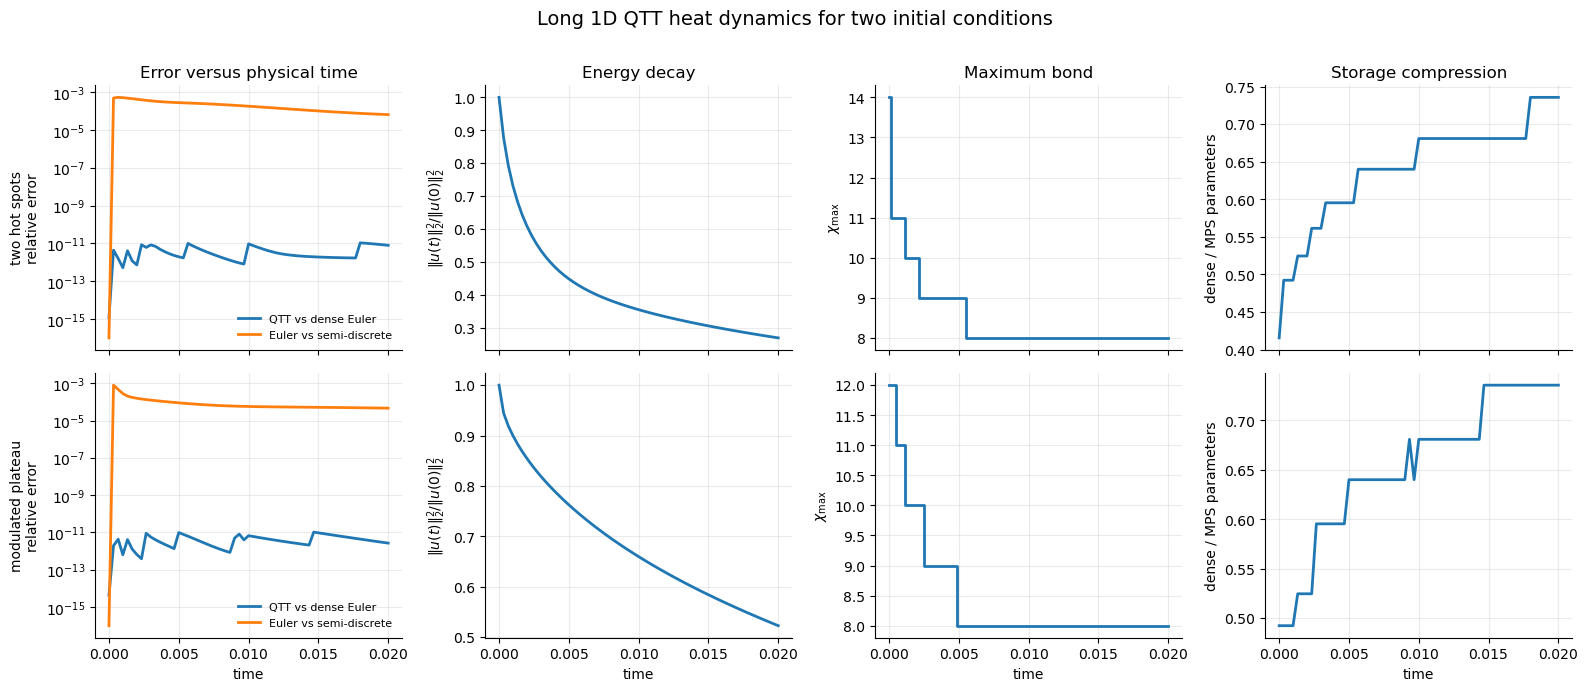

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6.8), sharex="col")
for row, (name, result) in enumerate(long_1d.items()):
    t = result["time"]
    axes[row, 0].semilogy(t, np.maximum(result["qtt_error"], 1e-16), lw=2,
                          label="QTT vs dense Euler")
    axes[row, 0].semilogy(t, np.maximum(result["euler_error"], 1e-16), lw=2,
                          label="Euler vs semi-discrete")
    axes[row, 1].plot(t, result["energy_ratio"], lw=2)
    axes[row, 2].step(t, result["max_bond"], where="mid", lw=2)
    axes[row, 3].plot(t, result["compression"], lw=2)

    axes[row, 0].set_ylabel(f"{name}\nrelative error")
    axes[row, 1].set_ylabel(r"$\|u(t)\|_2^2/\|u(0)\|_2^2$")
    axes[row, 2].set_ylabel(r"$\chi_{\max}$")
    axes[row, 3].set_ylabel("dense / MPS parameters")

for ax, title in zip(axes[0], ["Error versus physical time", "Energy decay",
                                "Maximum bond", "Storage compression"]):
    ax.set_title(title)
for ax in axes[-1]:
    ax.set_xlabel("time")
for ax in axes[:, 0]:
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Long 1D QTT heat dynamics for two initial conditions", fontsize=14, y=1.01)
plt.tight_layout()

Saved /Users/stefanopisoni/Documents/Work/QTADE-Bilbao-school/qtade-lecture/notes/figures/heat-1d-qtmps-long.gif


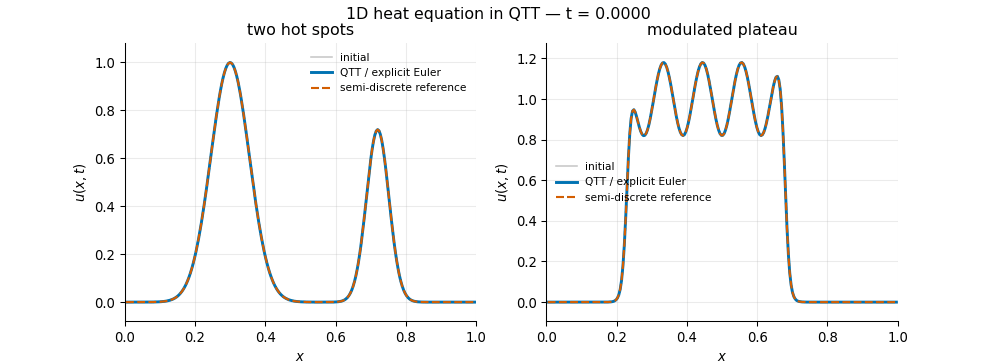

In [27]:
gif_1d_path = FIGURE_DIR / "heat-1d-qtmps-long.gif"

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
animation_lines = []
for ax, (name, u0) in zip(axes, initial_1d.items()):
    result = long_1d[name]
    ax.plot(x_long, u0, color="0.78", lw=1.2, label="initial")
    line_qtt, = ax.plot(x_long, result["frames"][0], color="#0072B2", lw=2.2,
                        label="QTT / explicit Euler")
    line_reference, = ax.plot(x_long, result["reference_frames"][0], "--",
                              color="#D55E00", lw=1.6, label="semi-discrete reference")
    margin = 0.08 * max(np.ptp(u0), 1.0)
    ax.set(xlim=(0, 1), ylim=(min(0.0, u0.min()) - margin, u0.max() + margin),
           xlabel="$x$", ylabel="$u(x,t)$", title=name)
    ax.legend(frameon=False, fontsize=8)
    animation_lines.append((line_qtt, line_reference))

time_label = fig.suptitle("")

def update_1d(frame):
    for (name, result), (line_qtt, line_reference) in zip(long_1d.items(), animation_lines):
        line_qtt.set_ydata(result["frames"][frame])
        line_reference.set_ydata(result["reference_frames"][frame])
    time_label.set_text(f"1D heat equation in QTT — t = {next(iter(long_1d.values()))['time'][frame]:.4f}")
    return [line for pair in animation_lines for line in pair] + [time_label]

animation_1d = FuncAnimation(fig, update_1d, frames=len(next(iter(long_1d.values()))["time"]),
                             interval=80, blit=False)
animation_1d.save(gif_1d_path, writer=PillowWriter(fps=12), dpi=95)
plt.close(fig)
print(f"Saved {gif_1d_path}")
display(Image(filename=str(gif_1d_path)))

## 12. Long 2D dynamics: two initial conditions and two orderings

The 2D examples are deliberately less separable than the modal benchmark:

1. **two hot spots** with different widths and orientations;
2. a **rotated ridge**, which introduces strong diagonal $x$--$y$ correlation.

Each physical problem is evolved twice—once in stacked order and once in interleaved order. The dense Euler reference is identical; only the tensor layout changes.

In [28]:
xy_long = np.arange(1, M_LONG_2D + 1) * H_LONG_2D
X_long, Y_long = np.meshgrid(xy_long, xy_long, indexing="ij")
boundary_envelope = np.sin(np.pi * X_long) * np.sin(np.pi * Y_long)

theta = np.deg2rad(32.0)
x_rot = (X_long - 0.50) * np.cos(theta) + (Y_long - 0.50) * np.sin(theta)
y_rot = -(X_long - 0.50) * np.sin(theta) + (Y_long - 0.50) * np.cos(theta)

initial_2d = {
    "two hot spots": boundary_envelope * (
        1.15 * np.exp(-((X_long - 0.30)**2 / 0.040**2 + (Y_long - 0.36)**2 / 0.075**2))
        + 0.85 * np.exp(-((X_long - 0.72)**2 / 0.075**2 + (Y_long - 0.64)**2 / 0.045**2))
    ),
    "rotated ridge": boundary_envelope * np.exp(
        -(x_rot / 0.29)**2 - (y_rot / 0.048)**2
    ),
}

long_2d = {}
for name, u0 in initial_2d.items():
    long_2d[name] = {}
    for ordering in ("stacked", "interleaved"):
        print(f"Running 2D case: {name}, {ordering}")
        long_2d[name][ordering] = run_long_2d(
            u0, ordering, cutoff=1e-10, max_bond=48
        )

print("\ncase                 ordering       QTT error   Euler error   max chi   compression   wall")
for name, by_ordering in long_2d.items():
    for ordering, result in by_ordering.items():
        print(f"{name:20s} {ordering:11s} {result['qtt_error'][-1]:11.3e} "
              f"{result['euler_error'][-1]:13.3e} {int(result['max_bond'][-1]):9d} "
              f"{result['compression'][-1]:11.1f}x {result['wall_time'][-1]:7.2f} s")

Running 2D case: two hot spots, stacked
Running 2D case: two hot spots, interleaved
Running 2D case: rotated ridge, stacked
Running 2D case: rotated ridge, interleaved

case                 ordering       QTT error   Euler error   max chi   compression   wall
two hot spots        stacked       1.206e-10     9.235e-04        10         4.8x    1.58 s
two hot spots        interleaved   1.293e-10     9.235e-04        33         0.7x    2.96 s
rotated ridge        stacked       1.260e-10     7.538e-04        10         4.4x    1.60 s
rotated ridge        interleaved   1.181e-10     7.538e-04        31         0.7x    3.08 s


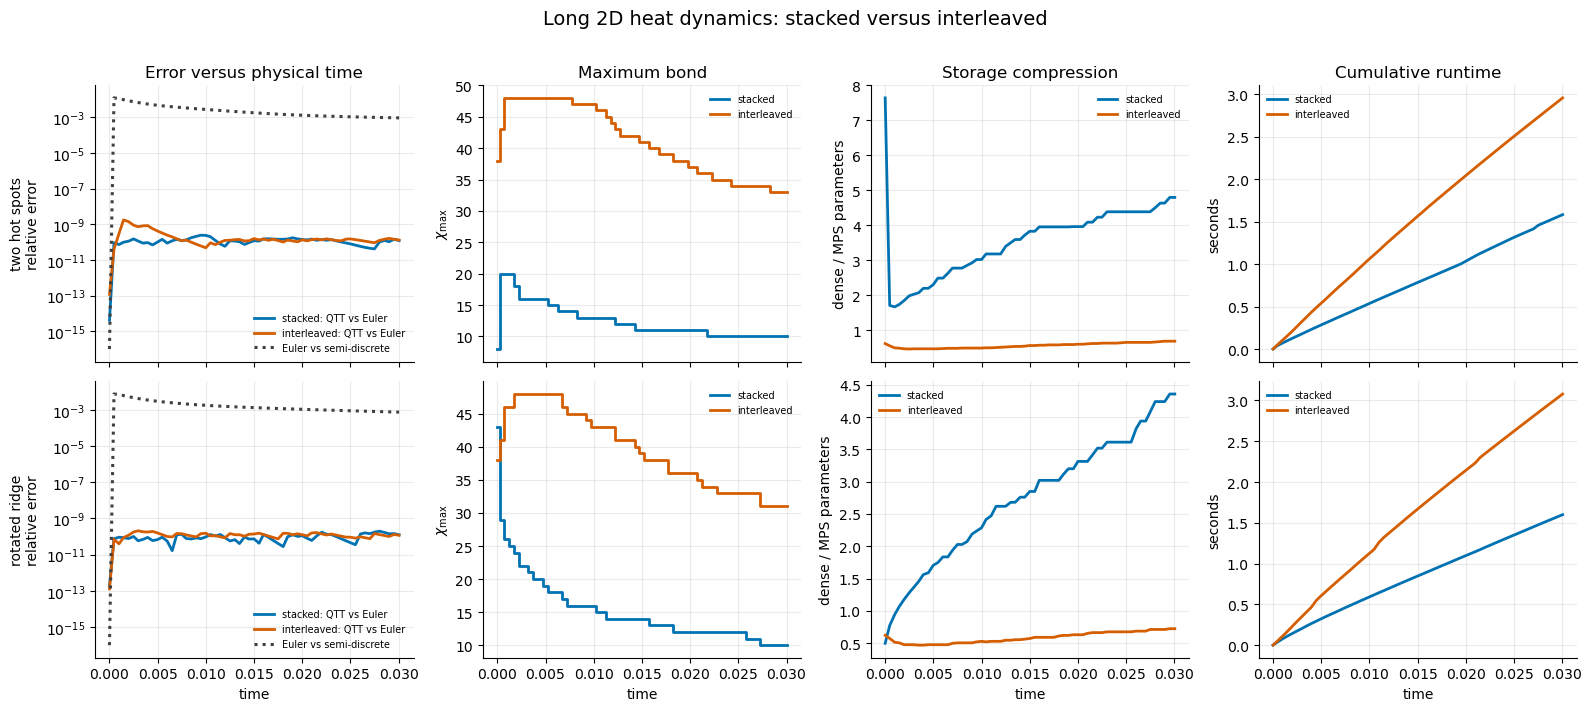

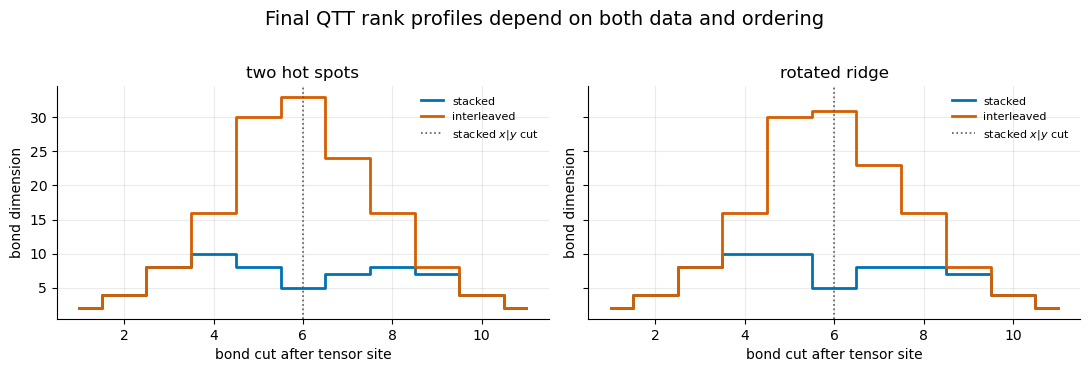

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.0), sharex="col")
for row, (name, by_ordering) in enumerate(long_2d.items()):
    for ordering, result in by_ordering.items():
        t = result["time"]
        color = COLORS[ordering]
        axes[row, 0].semilogy(t, np.maximum(result["qtt_error"], 1e-16),
                              color=color, lw=2, label=f"{ordering}: QTT vs Euler")
        axes[row, 1].step(t, result["max_bond"], where="mid",
                          color=color, lw=2, label=ordering)
        axes[row, 2].plot(t, result["compression"], color=color, lw=2, label=ordering)
        axes[row, 3].plot(t, result["wall_time"], color=color, lw=2, label=ordering)

    # Euler error is independent of tensor ordering, so draw it only once.
    reference_result = by_ordering["stacked"]
    axes[row, 0].semilogy(reference_result["time"],
                          np.maximum(reference_result["euler_error"], 1e-16),
                          color="0.25", ls=":", lw=2.2,
                          label="Euler vs semi-discrete")
    axes[row, 0].set_ylabel(f"{name}\nrelative error")
    axes[row, 1].set_ylabel(r"$\chi_{\max}$")
    axes[row, 2].set_ylabel("dense / MPS parameters")
    axes[row, 3].set_ylabel("seconds")

for ax, title in zip(axes[0], ["Error versus physical time", "Maximum bond",
                                "Storage compression", "Cumulative runtime"]):
    ax.set_title(title)
for ax in axes[-1]:
    ax.set_xlabel("time")
for ax in axes.flat:
    ax.legend(frameon=False, fontsize=7)
fig.suptitle("Long 2D heat dynamics: stacked versus interleaved", fontsize=14, y=1.01)
plt.tight_layout()


fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (name, by_ordering) in zip(axes, long_2d.items()):
    for ordering, result in by_ordering.items():
        ranks = result["final_ranks"][1:-1]
        ax.step(np.arange(1, 2 * N_LONG_2D), ranks, where="mid", lw=2,
                color=COLORS[ordering], label=ordering)
    ax.axvline(N_LONG_2D, color="0.35", ls=":", lw=1.2, label="stacked $x|y$ cut")
    ax.set(title=name, xlabel="bond cut after tensor site", ylabel="bond dimension")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Final QTT rank profiles depend on both data and ordering", fontsize=14, y=1.02)
plt.tight_layout()

Saved /Users/stefanopisoni/Documents/Work/QTADE-Bilbao-school/qtade-lecture/notes/figures/heat-2d-qtmps-long.gif


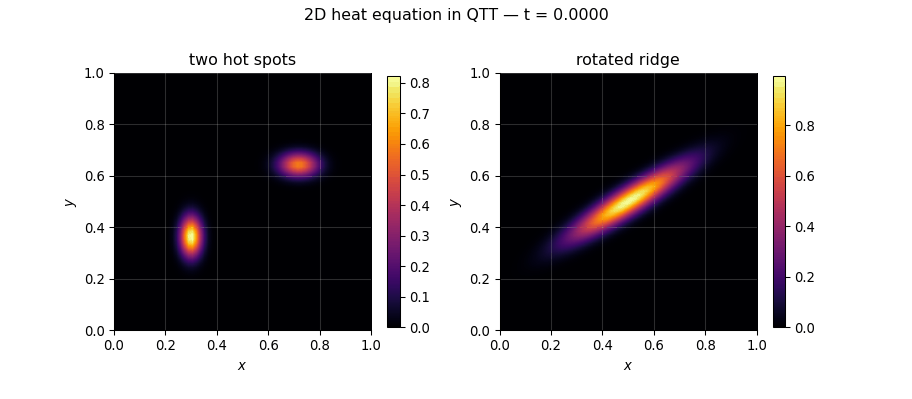

In [30]:
gif_2d_path = FIGURE_DIR / "heat-2d-qtmps-long.gif"

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
animation_images = []
for ax, (name, u0) in zip(axes, initial_2d.items()):
    result = long_2d[name]["interleaved"]
    image = ax.imshow(result["frames"][0].T, origin="lower", extent=(0, 1, 0, 1),
                      cmap="inferno", vmin=0.0, vmax=u0.max(), interpolation="bilinear")
    ax.set(title=name, xlabel="$x$", ylabel="$y$")
    fig.colorbar(image, ax=ax, shrink=0.82)
    animation_images.append(image)

time_label_2d = fig.suptitle("")

def update_2d(frame):
    for (name, by_ordering), image in zip(long_2d.items(), animation_images):
        image.set_data(by_ordering["interleaved"]["frames"][frame].T)
    sample = next(iter(long_2d.values()))["interleaved"]
    time_label_2d.set_text(f"2D heat equation in QTT — t = {sample['time'][frame]:.4f}")
    return animation_images + [time_label_2d]

animation_2d = FuncAnimation(fig, update_2d,
                             frames=len(next(iter(long_2d.values()))["interleaved"]["time"]),
                             interval=80, blit=False)
animation_2d.save(gif_2d_path, writer=PillowWriter(fps=12), dpi=95)
plt.close(fig)
print(f"Saved {gif_2d_path}")
display(Image(filename=str(gif_2d_path)))

## 13. Long-time observations

- The QTT error curves compare against **the identical dense Euler scheme**, so they measure representation and compression error rather than finite-difference error.
- The Euler-versus-semi-discrete curve grows much faster: once QTT truncation is controlled, the first-order timestep is the dominant error source.
- Diffusion rapidly removes short wavelengths. Ranks can therefore fall or plateau during heat evolution, even when the initial condition is not especially compressible.
- The ordering preference changes with the data. Stacked ordering is naturally economical for coordinate-separable structure; interleaving keeps equal binary scales adjacent and can help scale-local $x$--$y$ correlations.
- The GIFs visualize physical time rather than step count. Their smaller grids are a consequence of the explicit parabolic CFL condition, not a restriction of QTT storage.
- At only 256 points in 1D and $64^2$ in 2D, a generic MPS can store more numbers than the dense field. This finite-size overhead is why the long-time section is presented alongside—not instead of—the 20-qubit compression benchmark.

The generated animations are saved in `notes/figures/heat-1d-qtmps-long.gif` and `notes/figures/heat-2d-qtmps-long.gif`.